# Car Price Prediction using Machine Learning

## Objective
The objective of this project is to predict the selling price of used cars using machine learning techniques. The project involves data cleaning, feature engineering, exploratory data analysis, model building, and evaluation to identify the best regression model for price prediction.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv("car data.csv")

df.head()
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


2

In [5]:
df.isnull().sum()
df.duplicated().sum()
df.drop_duplicates(inplace=True)

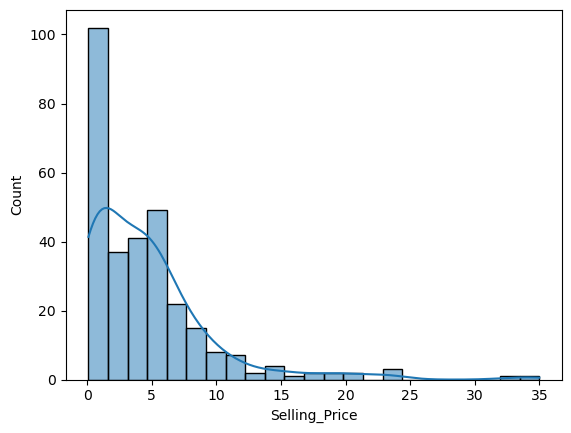

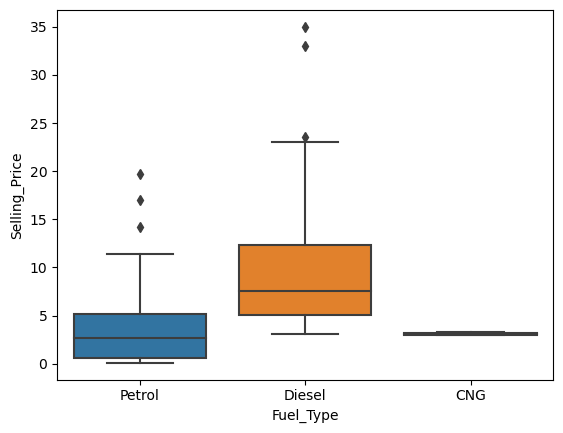

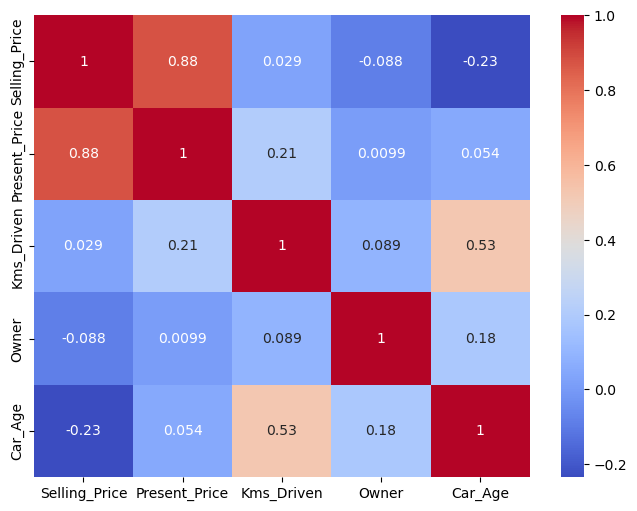

In [8]:
# Selling Price Distribution
sns.histplot(df["Selling_Price"], kde=True)
plt.show()

# Fuel Type vs Selling Price
sns.boxplot(x="Fuel_Type", y="Selling_Price", data=df)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()

## Feature Engineering

The dataset already contains the engineered features **Car_Age** and **Brand**, so no additional feature engineering was required before model training.

In [10]:
X = df.drop(["Selling_Price", "Car_Name"], axis=1)
y = df["Selling_Price"]

X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Linear Regression")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

print("\nRandom Forest")

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

Linear Regression
MAE : 1.8087830243665228
RMSE: 3.3993205771639428
R2 Score: 0.5516523951567558

Random Forest
MAE : 1.3971300000000004
RMSE: 3.3952814271672187
R2 Score: 0.5527172357821646


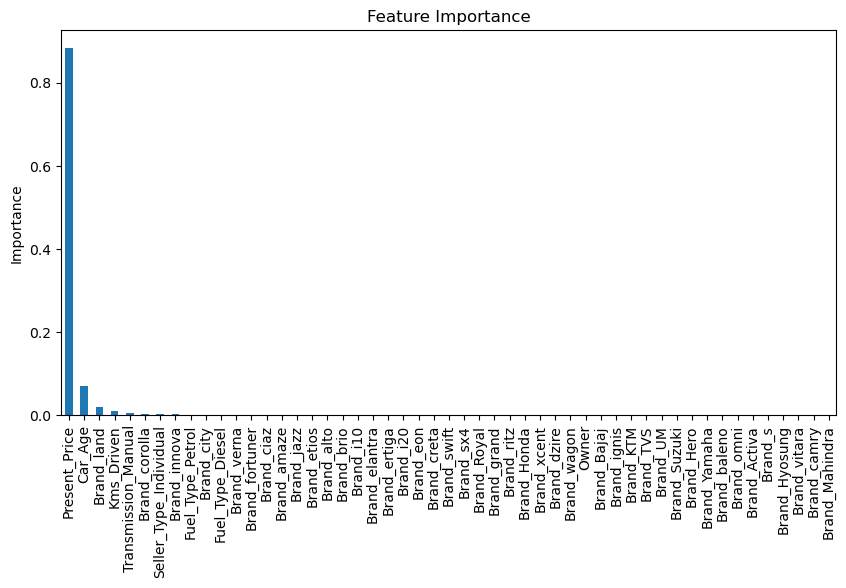

In [15]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))

plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

## Conclusion

- The dataset was cleaned and preprocessed successfully.
- Feature engineering was performed by creating the `Car_Age` and `Brand` features.
- Linear Regression and Random Forest models were trained and evaluated.
- Random Forest achieved better performance (higher R² and lower error) and was selected as the final model for car price prediction.